# PPP (patent–paper pair) — Citation-Trend Validation

Face-validity figures for the PPP trend outputs, rendered inline: coverage, the **citation-age profiles**
(paper→paper and patent→paper by years since publication; patent→patent by years since grant), per-pair
citation totals, and examiner vs non-examiner shares.

## Inputs
```
/project/jevans/Dawoon/Science of Science/PPP/output/ppp_paper_trend.parquet   # paperid, patent, pub_year, cite_year, yrs_since_pub, p2p, pat2p_examiner, pat2p_non_examiner
/project/jevans/Dawoon/Science of Science/PPP/output/ppp_patent_trend.parquet  # paperid, patent, grant_year, cite_year, yrs_since_grant, pat2pat_examiner, pat2pat_non_examiner
```

In [1]:
import os, sys
import numpy as np, pandas as pd
import duckdb
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110; plt.rcParams['axes.grid'] = True; plt.rcParams['grid.alpha'] = 0.3
sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/PPP')
import val_common as V
import ppp_common as P
V.init('ppp_validation')
ROOT = V.BASE

# ── Where the citation histories come from ────────────────────────────────────────────────
# Previously: PPP/output/ppp_{paper,patent}_trend.parquet, built by ppp_citation_trend.ipynb
# from its own scan of the citation sources -- so the trajectories existed only for the pairs
# that notebook happened to cover.
#
# Now: the DOCUMENT-level trends this project already produces, joined onto the pair list.
#   OpenAlex/output/paper_citation_trend.parquet    584,136,859 rows, every scored paper
#   PatentView/output/patent_citation_trend.parquet  50,546,229 rows, every scored patent
# The measure columns are the same names and the same quantities (p2p, pat2p_*, pat2pat_*),
# so nothing downstream changes; what changes is that a pair is now limited by whether its
# two DOCUMENTS have a citation history, not by a separate pair-level build.
PAP_TREND = V.paper('paper_citation_trend.parquet')
PAT_TREND = V.patent('patent_citation_trend.parquet')
for _p in (PAP_TREND, PAT_TREND):
    if not os.path.exists(_p):
        raise SystemExit(f'{_p} is missing — run the OpenAlex / PatentView notebook that '
                         f'writes it before this one.')

con = duckdb.connect(); con.execute("SET memory_limit='24GB'")
con.execute(f"SET temp_directory='{V.BASE}/.duckdb_tmp'")

pairs = P.load_pairs()          # NB_PAIRS_SOURCE=full switches to the 548k list
con.register('pairs', pairs[['paperid', 'patent', 'oaid', 'patent_id']])
V.preflight()
print(f'\npaper trend : {PAP_TREND}')
print(f'patent trend: {PAT_TREND}')

[val] ppp_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/ppp_validation_<section>.{jpg,pdf}  @ 600 dpi
[ppp] pairs 'plus': _patent_paper_pairs_plus.csv -> 548,315 pairs | 335,917 distinct papers | 309,729 distinct patents
  ppp_validation      OK

paper trend : /project/jevans/Dawoon/Science of Science/OpenAlex/output/paper_citation_trend.parquet
patent trend: /project/jevans/Dawoon/Science of Science/PatentView/output/patent_citation_trend.parquet


## 1. Load trend tables + coverage

In [2]:
%%time
# One row per (pair, citing year), assembled by joining each side's document-level history
# onto the pair list. A pair contributes on the paper side if its PAPER has a history and on
# the patent side if its PATENT does; the two sides are therefore not guaranteed to cover the
# same pairs, which is why the counts below are reported separately.
pt = con.execute(f"""
    SELECT p.paperid, p.patent, t.pub_year, t.cite_year, t.yrs_since_pub,
           t.p2p, t.pat2p_examiner, t.pat2p_non_examiner
    FROM pairs p
    JOIN read_parquet('{PAP_TREND}') t ON t.paper_id = p.paperid
""").fetchdf()

qt = con.execute(f"""
    SELECT p.paperid, p.patent, t.grant_year, t.cite_year, t.yrs_since_grant,
           t.pat2pat_examiner, t.pat2pat_non_examiner
    FROM pairs p
    JOIN read_parquet('{PAT_TREND}') t ON t.patent_id = p.patent_id
""").fetchdf()

n_pairs_paper = pt[['paperid', 'patent']].drop_duplicates().shape[0]
n_pairs_pat = qt[['paperid', 'patent']].drop_duplicates().shape[0]
print(f'paper-side rows {len(pt):,} over {n_pairs_paper:,} pairs | '
      f'patent-side rows {len(qt):,} over {n_pairs_pat:,} pairs')
print(f'  of {len(pairs):,} pairs in the list: '
      f'{n_pairs_paper/len(pairs)*100:.1f}% have a paper history, '
      f'{n_pairs_pat/len(pairs)*100:.1f}% a patent history')
print('paper-side cols:', list(pt.columns)); print('patent-side cols:', list(qt.columns))
display(pt.head(4)); display(qt.head(4))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



paper-side rows 5,762,052 over 447,206 pairs | patent-side rows 3,633,657 over 477,648 pairs
  of 548,315 pairs in the list: 81.6% have a paper history, 87.1% a patent history
paper-side cols: ['paperid', 'patent', 'pub_year', 'cite_year', 'yrs_since_pub', 'p2p', 'pat2p_examiner', 'pat2p_non_examiner']
patent-side cols: ['paperid', 'patent', 'grant_year', 'cite_year', 'yrs_since_grant', 'pat2pat_examiner', 'pat2pat_non_examiner']


,paperid,patent,pub_year,cite_year,yrs_since_pub,p2p,pat2p_examiner,pat2p_non_examiner
0,W233685,US-7825199,1996,1998,2,2,0,0
1,W233685,US-7825199,1996,2001,5,1,0,0
2,W233685,US-7825199,1996,2007,11,1,0,0
3,W233685,US-7825199,1996,2013,17,1,0,0


,paperid,patent,grant_year,cite_year,yrs_since_grant,pat2pat_examiner,pat2pat_non_examiner
0,W2025049717,US-10000036,2018,2022,4,0,1
1,W2025049717,US-10000036,2018,2024,6,0,0
2,W2346689143,US-10000103,2018,2018,0,0,0
3,W2346689143,US-10000103,2018,2019,1,0,0


CPU times: user 43.3 s, sys: 3.34 s, total: 46.7 s
Wall time: 41.8 s


## 2. Citation-age profiles (per-pair average vs years since publication / grant)

  [fig] ppp_validation_2.jpg + .pdf  (600 dpi)


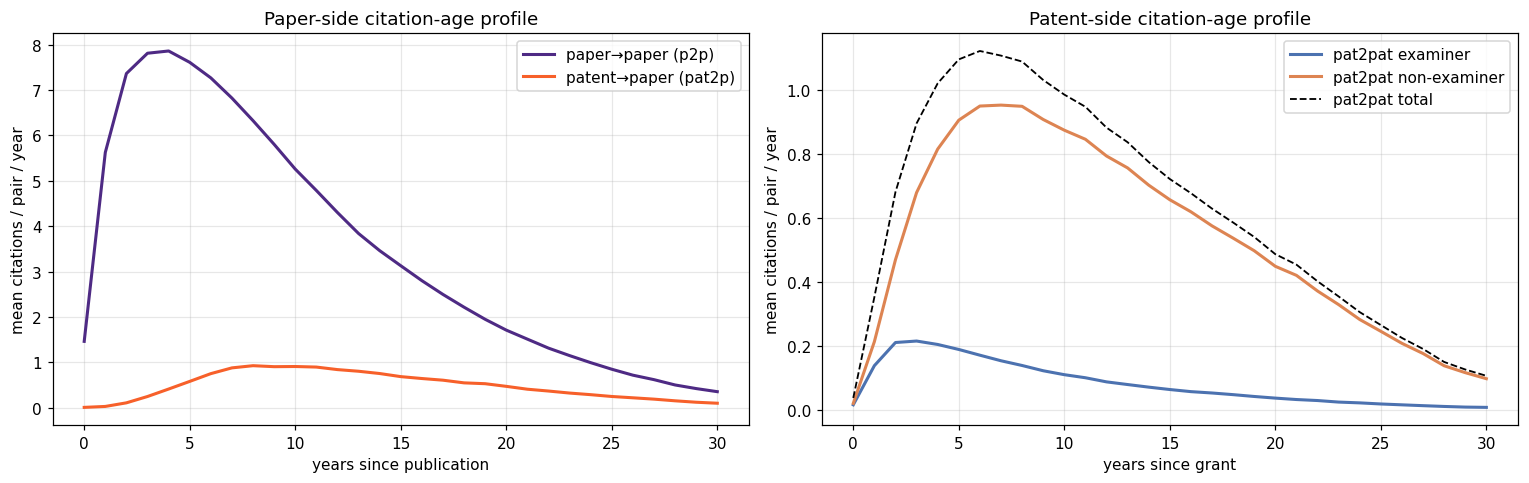

['/project/jevans/Dawoon/Science of Science/validation/Figures/ppp_validation_2.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/ppp_validation_2.pdf']

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
# paper side: average per pair at each offset = sum over rows / #pairs
mp = pt[pt['yrs_since_pub'].between(0, 30)]
prof = mp.groupby('yrs_since_pub')[['p2p', 'pat2p_examiner', 'pat2p_non_examiner']].sum() / n_pairs_paper
prof['p2p'].plot(ax=ax[0], color='#4E2A84', lw=2, label='paper→paper (p2p)')
(prof['pat2p_examiner'] + prof['pat2p_non_examiner']).plot(ax=ax[0], color='#F7602A', lw=2, label='patent→paper (pat2p)')
ax[0].set_title('Paper-side citation-age profile'); ax[0].set_xlabel('years since publication')
ax[0].set_ylabel('mean citations / pair / year'); ax[0].legend()
# patent side
mq = qt[qt['yrs_since_grant'].between(0, 30)]
profq = mq.groupby('yrs_since_grant')[['pat2pat_examiner', 'pat2pat_non_examiner']].sum() / n_pairs_pat
profq['pat2pat_examiner'].plot(ax=ax[1], color='#4c72b0', lw=2, label='pat2pat examiner')
profq['pat2pat_non_examiner'].plot(ax=ax[1], color='#dd8452', lw=2, label='pat2pat non-examiner')
(profq['pat2pat_examiner'] + profq['pat2pat_non_examiner']).plot(ax=ax[1], color='k', lw=1.2, ls='--', label='pat2pat total')
ax[1].set_title('Patent-side citation-age profile'); ax[1].set_xlabel('years since grant')
ax[1].set_ylabel('mean citations / pair / year'); ax[1].legend()
plt.tight_layout(); V.save('2')

## 3. Per-pair citation totals (distribution) + examiner/non-examiner share

  [fig] ppp_validation_3.jpg + .pdf  (600 dpi)


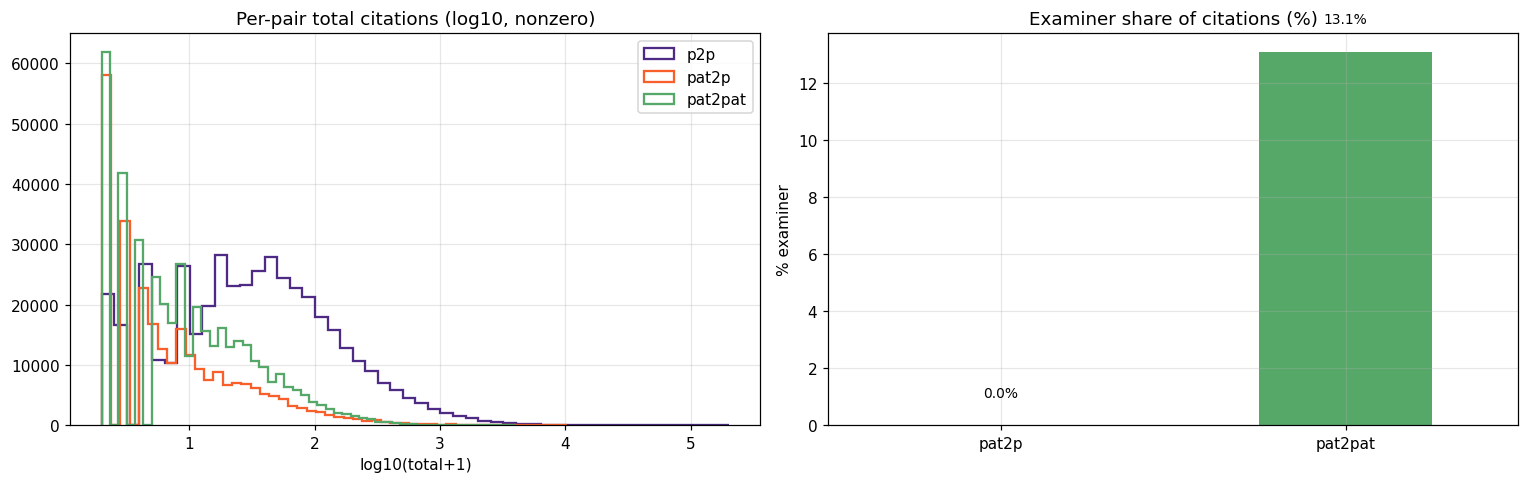

per-pair means: p2p 110.07 | pat2p 15.28 | pat2pat 19.62


In [4]:
tot_p = pt.groupby(['paperid', 'patent']).agg(
    p2p=('p2p', 'sum'), pat2p_exm=('pat2p_examiner', 'sum'), pat2p_nex=('pat2p_non_examiner', 'sum')).reset_index()
tot_q = qt.groupby(['paperid', 'patent']).agg(
    pat2pat_exm=('pat2pat_examiner', 'sum'), pat2pat_nex=('pat2pat_non_examiner', 'sum')).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for col, lab, cc in [(tot_p['p2p'], 'p2p', '#4E2A84'),
                     (tot_p['pat2p_exm'] + tot_p['pat2p_nex'], 'pat2p', '#F7602A'),
                     (tot_q['pat2pat_exm'] + tot_q['pat2pat_nex'], 'pat2pat', '#55a868')]:
    v = col[col > 0]
    ax[0].hist(np.log10(v + 1), bins=50, histtype='step', label=lab, color=cc, linewidth=1.5)
ax[0].set_title('Per-pair total citations (log10, nonzero)'); ax[0].set_xlabel('log10(total+1)'); ax[0].legend()
shares = pd.Series({
    'pat2p': tot_p['pat2p_exm'].sum() / max(tot_p['pat2p_exm'].sum() + tot_p['pat2p_nex'].sum(), 1),
    'pat2pat': tot_q['pat2pat_exm'].sum() / max(tot_q['pat2pat_exm'].sum() + tot_q['pat2pat_nex'].sum(), 1),
})
(shares * 100).plot.bar(ax=ax[1], color=['#F7602A', '#55a868'])
ax[1].set_title('Examiner share of citations (%)'); ax[1].set_ylabel('% examiner'); plt.setp(ax[1].get_xticklabels(), rotation=0)
for i, v in enumerate(shares.values): ax[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); V.save('3')
print('per-pair means: p2p %.2f | pat2p %.2f | pat2pat %.2f' % (
    tot_p['p2p'].mean(), (tot_p['pat2p_exm'] + tot_p['pat2p_nex']).mean(),
    (tot_q['pat2pat_exm'] + tot_q['pat2pat_nex']).mean()))

## 4. Scientific vs technological impact (p2p vs pat2p, per pair)

  [fig] ppp_validation_4.jpg + .pdf  (600 dpi)


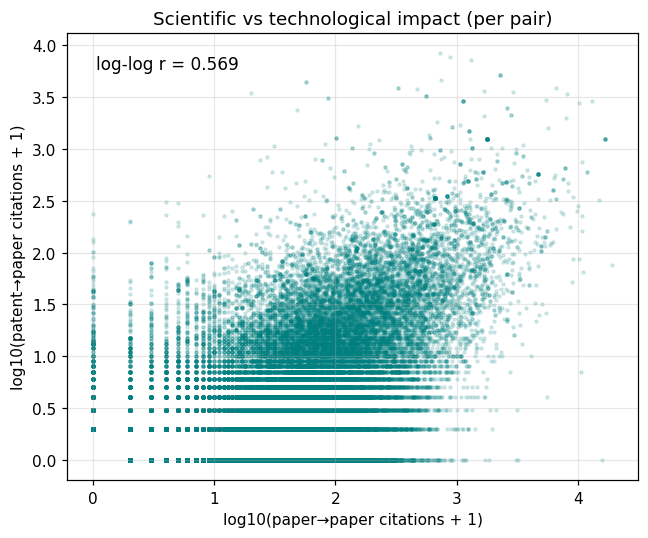

done — all PPP validation figures rendered inline.


In [5]:
s = tot_p.sample(min(60000, len(tot_p)), random_state=0)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np.log10(s['p2p'] + 1), np.log10(s['pat2p_exm'] + s['pat2p_nex'] + 1), s=4, alpha=0.15, color='teal')
ax.set_xlabel('log10(paper→paper citations + 1)'); ax.set_ylabel('log10(patent→paper citations + 1)')
ax.set_title('Scientific vs technological impact (per pair)')
r = np.corrcoef(np.log10(tot_p['p2p'] + 1), np.log10(tot_p['pat2p_exm'] + tot_p['pat2p_nex'] + 1))[0, 1]
ax.text(0.05, 0.92, f'log-log r = {r:.3f}', transform=ax.transAxes, fontsize=11)
plt.tight_layout(); V.save('4')
print('done — all PPP validation figures rendered inline.')

## 5. Cumulative citation trajectories — convexity vs concavity (min–max scaled)

For each pair we build the **cumulative** citation curve and **min–max scale both axes to [0,1]**
(x = normalized time, y = normalized cumulative citations), so shape is comparable across pairs:
- **Paper trajectory** = paper→paper (`p2p`) cumulative by years since publication — **red**.
- **Patent trajectory** = patent→patent (`pat2pat`) cumulative by years since grant — **blue**.

A curve **below** the diagonal is **convex** (slow start, accelerating); **above** is **concave** (fast
start, saturating). We quantify with the area under the normalized curve, the **convexity index** (`<0.5` convex,
`>0.5` concave). Hypothesis under test: paper convex, patent concave.

In [ ]:
%%time
RED, BLUE = '#d62728', '#1f77b4'
GRID = np.linspace(0, 1, 21)
MIN_TOTAL, MIN_SPAN = 10, 5
qt['pat2pat'] = qt['pat2pat_examiner'] + qt['pat2pat_non_examiner']

pp = pt.groupby(['paperid', 'patent']).agg(p2p_tot=('p2p', 'sum'), p2p_span=('yrs_since_pub', 'max')).reset_index()
qq = qt.groupby(['paperid', 'patent']).agg(pat_tot=('pat2pat', 'sum'), pat_span=('yrs_since_grant', 'max')).reset_index()
both = pp.merge(qq, on=['paperid', 'patent'])
sel = both[(both.p2p_tot >= MIN_TOTAL) & (both.p2p_span >= MIN_SPAN) &
           (both.pat_tot >= MIN_TOTAL) & (both.pat_span >= MIN_SPAN)].copy()
print(f'pairs with sufficient signal on both sides (ALL used): {len(sel):,}')

# attach paper FoS (level-0) + patent CPC section
meta = pd.read_parquet(V.paper('paper_metadata.parquet'),
                       columns=['paper_id', 'FoS_rep']).rename(columns={'paper_id': 'paperid'})
sel = sel.merge(meta, on='paperid', how='left')
pcpc = pd.read_parquet(V.patent('patent_metadata.parquet'),
                       columns=['patent_id', 'cpc_code'])
pcpc['cpc_section'] = pcpc['cpc_code'].str[0]
sel['patent_id'] = sel['patent'].str.extract(r'[Uu][Ss]-0*([0-9]+)', expand=False)
sel = sel.merge(pcpc[['patent_id', 'cpc_section']], on='patent_id', how='left')
print(f'ALL {len(sel):,} pairs | with FoS {sel.FoS_rep.notna().mean()*100:.0f}% | with CPC section {sel.cpc_section.notna().mean()*100:.0f}%')

def traj_matrix(df, keys_df, off, valcol):
    sub = df.merge(keys_df[['paperid', 'patent']], on=['paperid', 'patent'], how='inner')
    mats = {}
    for k, g in sub.groupby(['paperid', 'patent']):
        s = g.groupby(off)[valcol].sum().sort_index()
        years = s.index.values.astype(float); cum = np.cumsum(s.values).astype(float)
        if cum[-1] <= 0 or years[-1] <= 0: continue
        xt = np.concatenate([[0.0], years / years[-1]]); yt = np.concatenate([[0.0], cum / cum[-1]])
        mats[k] = np.interp(GRID, xt, yt)
    return mats

paper_mats = traj_matrix(pt, sel, 'yrs_since_pub', 'p2p')
patent_mats = traj_matrix(qt, sel, 'yrs_since_grant', 'pat2pat')
common = [k for k in paper_mats if k in patent_mats]
PM = np.array([paper_mats[k] for k in common]); QM = np.array([patent_mats[k] for k in common])
info = sel.set_index(['paperid', 'patent'])
FoS_arr = info['FoS_rep'].reindex(common).values
SEC_arr = info['cpc_section'].reindex(common).values
def cvx(m): return np.trapz(m, GRID, axis=-1)
print(f'trajectory pairs (both sides): {len(common):,}  |  '
      f'paper convexity index {cvx(PM.mean(0)):.3f}  patent convexity index {cvx(QM.mean(0)):.3f}')

pairs with sufficient signal on both sides (ALL used): 107,260


### 5a. Individual example pairs (each min–max scaled; red = paper, blue = patent)

In [ ]:
# pick 9 well-populated example pairs (highest combined citations)
order = np.argsort(-(sel.set_index(['paperid', 'patent']).reindex(common)['p2p_tot'].values +
                     sel.set_index(['paperid', 'patent']).reindex(common)['pat_tot'].values))
ex = [common[i] for i in order[:9]]
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for ax, k in zip(axes.flat, ex):
    ax.plot(GRID, paper_mats[k], color=RED, lw=2, label='paper (p2p)')
    ax.plot(GRID, patent_mats[k], color=BLUE, lw=2, label='patent (pat2pat)')
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{k[1]}\\nconvexity paper {cvx(paper_mats[k]):.2f} / patent {cvx(patent_mats[k]):.2f}', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes.flat[0].legend(fontsize=8)
fig.suptitle('Individual PPP pairs — cumulative citation trajectory (min–max scaled)', y=1.0)
plt.tight_layout(); V.save('5a')

### 5b. Overall average trajectory (all sampled pairs)

In [ ]:
mp, sp = PM.mean(0), PM.std(0); mq, sq = QM.mean(0), QM.std(0)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(GRID, mp, color=RED, lw=2.5, label=f'paper (p2p)  convexity index={cvx(mp):.3f}')
ax.fill_between(GRID, mp - sp, mp + sp, color=RED, alpha=0.12)
ax.plot(GRID, mq, color=BLUE, lw=2.5, label=f'patent (pat2pat)  convexity index={cvx(mq):.3f}')
ax.fill_between(GRID, mq - sq, mq + sq, color=BLUE, alpha=0.12)
ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label='diagonal (convexity index=0.5)')
ax.set_xlabel('normalized time (0 = pub/grant, 1 = last citation)'); ax.set_ylabel('normalized cumulative citations')
ax.set_title(f'Average cumulative trajectory (n={len(common):,} pairs)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc='lower right')
pa, qa = cvx(mp), cvx(mq)
ax.text(0.03, 0.93, f"paper: {'convex' if pa<0.5 else 'concave'}  |  patent: {'convex' if qa<0.5 else 'concave'}",
        transform=ax.transAxes, fontsize=11, weight='bold')
plt.tight_layout(); V.save('5b')

### 5c. Panel by CPC section (patent) — mean trajectories

In [ ]:
secs = list(pd.Series(SEC_arr).dropna().value_counts().index)
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, sc in zip(axes.flat, secs[:9]):
    idx = np.where(SEC_arr == sc)[0]
    if len(idx) < 20: ax.set_visible(False); continue
    mpi, mqi = PM[idx].mean(0), QM[idx].mean(0)
    ax.plot(GRID, mpi, color=RED, lw=2); ax.plot(GRID, mqi, color=BLUE, lw=2)
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{sc}  (n={len(idx):,})\\nconvexity paper {cvx(mpi):.2f} / patent {cvx(mqi):.2f}', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for ax in axes.flat[len(secs[:9]):]: ax.set_visible(False)
fig.suptitle('Cumulative trajectory by CPC section (red=paper, blue=patent)', y=1.0)
plt.tight_layout(); V.save('5c')

### 5d. Panel by Field of Study (paper) — mean trajectories

In [ ]:
tops = pd.Series(FoS_arr).dropna().value_counts().head(8).index
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, fs in zip(axes.flat, tops):
    idx = np.where(FoS_arr == fs)[0]
    if len(idx) < 20: ax.set_visible(False); continue
    mpi, mqi = PM[idx].mean(0), QM[idx].mean(0)
    ax.plot(GRID, mpi, color=RED, lw=2); ax.plot(GRID, mqi, color=BLUE, lw=2)
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{fs}  (n={len(idx):,})\\nconvexity paper {cvx(mpi):.2f} / patent {cvx(mqi):.2f}', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for ax in axes.flat[len(tops):]: ax.set_visible(False)
fig.suptitle('Cumulative trajectory by Field of Study (red=paper, blue=patent)', y=1.0)
plt.tight_layout(); V.save('5d')
print('done — convexity/concavity analysis rendered inline.')

## 6. Sleeping-beauty pairs — convexity analysis

Sleeping beauties (dormant, then a late citation burst) should have **convex** cumulative trajectories
(low convexity index). Using the Ke et al. beauty coefficient `SB_B` from `paper_sb`/`patent_sb`, we (a) show the top
sleeping-beauty examples, (b) compare the high-SB average trajectory to the overall, and (c) test whether
higher `SB_B` ⇒ lower convexity index (more convex). Paper SB → paper (p2p) trajectory (**red**); patent SB →
patent (pat2pat) trajectory (**blue**).

In [ ]:
%%time
psb = pd.read_parquet(V.paper('paper_sb.parquet'),
                      columns=['paper_id', 'SB_B']).rename(columns={'paper_id': 'paperid', 'SB_B': 'paper_SB_B'})
tsb = pd.read_parquet(V.patent('patent_sb.parquet'),
                      columns=['patent_id', 'SB_B']).rename(columns={'SB_B': 'patent_SB_B'})

# (c) SB for the 20k sample -> per-pair convexity index vs SB
selk = sel.merge(psb, on='paperid', how='left').merge(tsb, on='patent_id', how='left')
mp_ = selk.set_index(['paperid', 'patent'])['paper_SB_B']; mt_ = selk.set_index(['paperid', 'patent'])['patent_SB_B']
paper_cvx = cvx(PM); patent_cvx = cvx(QM)
paper_SB = np.array([mp_.get(k, np.nan) for k in common]); patent_SB = np.array([mt_.get(k, np.nan) for k in common])

# (a,b) high-SB subsets from the full sufficient-signal population
sig = both[(both.p2p_tot >= MIN_TOTAL) & (both.p2p_span >= MIN_SPAN) &
           (both.pat_tot >= MIN_TOTAL) & (both.pat_span >= MIN_SPAN)].copy()
sig['patent_id'] = sig['patent'].str.extract(r'[Uu][Ss]-0*([0-9]+)', expand=False)
sig = sig.merge(psb, on='paperid', how='left').merge(tsb, on='patent_id', how='left')
NTOP = 3000
hi_p = sig.dropna(subset=['paper_SB_B']).nlargest(NTOP, 'paper_SB_B').reset_index(drop=True)
hi_t = sig.dropna(subset=['patent_SB_B']).nlargest(NTOP, 'patent_SB_B').reset_index(drop=True)
hp_mats = traj_matrix(pt, hi_p, 'yrs_since_pub', 'p2p')
ht_mats = traj_matrix(qt, hi_t, 'yrs_since_grant', 'pat2pat')
HP = np.array(list(hp_mats.values())); HT = np.array(list(ht_mats.values()))
print(f'high paper-SB: {len(HP):,} paper-traj, convexity index {cvx(HP.mean(0)):.3f}  (overall paper convexity index {cvx(PM.mean(0)):.3f})')
print(f'high patent-SB: {len(HT):,} patent-traj, convexity index {cvx(HT.mean(0)):.3f}  (overall patent convexity index {cvx(QM.mean(0)):.3f})')

### 6a. Top sleeping-beauty examples (red = high-SB paper p2p ; blue = high-SB patent pat2pat)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j in range(4):
    k = tuple(hi_p.loc[j, ['paperid', 'patent']]);
    ax = axes[0, j]
    if k in hp_mats:
        ax.plot(GRID, hp_mats[k], color=RED, lw=2)
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'paper {k[0]}\\nSB_B={hi_p.loc[j, "paper_SB_B"]:.0f}  convexity index={cvx(hp_mats[k]):.2f}' if k in hp_mats else 'n/a', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for j in range(4):
    k = tuple(hi_t.loc[j, ['paperid', 'patent']]); ax = axes[1, j]
    if k in ht_mats:
        ax.plot(GRID, ht_mats[k], color=BLUE, lw=2)
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'patent {k[1]}\\nSB_B={hi_t.loc[j, "patent_SB_B"]:.0f}  convexity index={cvx(ht_mats[k]):.2f}' if k in ht_mats else 'n/a', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.suptitle('Top sleeping beauties — cumulative trajectory (min–max scaled)', y=1.0)
plt.tight_layout(); V.save('6a')

### 6b. Average trajectory: high-SB vs all

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].plot(GRID, PM.mean(0), color=RED, ls='--', lw=2, label=f'all papers  convexity index={cvx(PM.mean(0)):.3f}')
ax[0].plot(GRID, HP.mean(0), color=RED, lw=2.5, label=f'high-SB papers  convexity index={cvx(HP.mean(0)):.3f}')
ax[1].plot(GRID, QM.mean(0), color=BLUE, ls='--', lw=2, label=f'all patents  convexity index={cvx(QM.mean(0)):.3f}')
ax[1].plot(GRID, HT.mean(0), color=BLUE, lw=2.5, label=f'high-SB patents  convexity index={cvx(HT.mean(0)):.3f}')
for a, t in zip(ax, ['Paper (p2p) trajectory', 'Patent (pat2pat) trajectory']):
    a.plot([0, 1], [0, 1], color='gray', ls=':', lw=1); a.set_xlim(0, 1); a.set_ylim(0, 1)
    a.set_xlabel('normalized time'); a.set_ylabel('normalized cumulative citations'); a.set_title(t); a.legend(loc='lower right')
plt.tight_layout(); V.save('6b')
print('Sleeping beauties should sit BELOW the diagonal (convex, low convexity index) vs the overall curve.')

### 6c. Convexity index vs beauty coefficient SB_B — deciles

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, sb, ac, col, lab in [(ax[0], paper_SB, paper_cvx, RED, 'paper (p2p)'),
                            (ax[1], patent_SB, patent_cvx, BLUE, 'patent (pat2pat)')]:
    m = np.isfinite(sb) & np.isfinite(ac)
    d = pd.DataFrame({'sb': sb[m], 'cvx': ac[m]})
    d['dec'] = pd.qcut(d['sb'].rank(method='first'), 10, labels=False)
    gg = d.groupby('dec').agg(sb=('sb', 'median'), cvx=('cvx', 'mean'), n=('cvx', 'size'))
    a.plot(gg['sb'], gg['cvx'], 'o-', color=col, lw=2, ms=6)
    a.axhline(0.5, color='gray', ls='--', lw=0.8)
    a.set_xlabel('median SB_B (decile)'); a.set_ylabel('mean convexity index'); a.set_title(f'{lab}: convexity index vs SB_B')
    r = np.corrcoef(d['sb'].rank(), d['cvx'])[0, 1]
    a.text(0.05, 0.05, f'Spearman(SB,convexity index) = {r:+.3f}\\n(lower convexity index = more convex)', transform=a.transAxes, fontsize=10)
plt.tight_layout(); V.save('6c')
print('done — sleeping-beauty convexity analysis rendered inline.')

## 7. Pairs where the paper is CONVEX and the patent is CONCAVE

Isolates PPP pairs with **paper convexity index < 0.5** (paper cumulative citations convex — late blooming) **and
patent convexity index > 0.5** (patent concave — early peak). This is the reverse of the average pattern, and is the
case the hypothesis originally guessed. We count all four quadrants, show the subset's average and example
trajectories, and its field / CPC-section composition.

In [ ]:
pa = cvx(PM); qa = cvx(QM)                       # per-pair paper / patent convexity index (ALL pairs)
q_cc = pd.crosstab(pd.Series(np.where(pa < 0.5, 'paper convex', 'paper concave')),
                   pd.Series(np.where(qa < 0.5, 'patent convex', 'patent concave')))
print('quadrant counts (n pairs):'); print(q_cc.to_string())
target = (pa < 0.5) & (qa > 0.5)
print(f'\\npaper-convex & patent-concave pairs: {int(target.sum()):,} ({target.mean()*100:.1f}% of {len(pa):,})')
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].plot(GRID, PM[target].mean(0), color=RED, lw=2.5, label=f'paper (convex)  convexity index={cvx(PM[target].mean(0)):.3f}')
ax[0].plot(GRID, QM[target].mean(0), color=BLUE, lw=2.5, label=f'patent (concave)  convexity index={cvx(QM[target].mean(0)):.3f}')
ax[0].plot(GRID, PM.mean(0), color=RED, ls=':', lw=1.3, alpha=0.6, label='paper (all)')
ax[0].plot(GRID, QM.mean(0), color=BLUE, ls=':', lw=1.3, alpha=0.6, label='patent (all)')
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
ax[0].set_title(f'Paper-convex + patent-concave subset (n={int(target.sum()):,})'); ax[0].legend(loc='lower right', fontsize=8)
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1); ax[0].set_xlabel('normalized time'); ax[0].set_ylabel('norm cumulative citations')
ax[1].scatter(pa, qa, s=3, alpha=0.06, color='gray')
ax[1].scatter(pa[target], qa[target], s=5, alpha=0.3, color='purple')
ax[1].axvline(0.5, color='k', ls='--', lw=0.8); ax[1].axhline(0.5, color='k', ls='--', lw=0.8)
ax[1].set_xlabel('paper convexity index (<0.5 convex)'); ax[1].set_ylabel('patent convexity index (>0.5 concave)')
ax[1].set_title('Paper vs patent convexity index (purple = target quadrant)'); ax[1].set_xlim(0, 1); ax[1].set_ylim(0, 1)
plt.tight_layout(); V.save('7')

### 7a. Example pairs (paper convex = red, patent concave = blue) + composition

In [ ]:
ti = np.where(target)[0]
score = (0.5 - pa[ti]) + (qa[ti] - 0.5)          # strongest paper-convex + patent-concave
ex = ti[np.argsort(-score)[:9]]
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for ax, i in zip(axes.flat, ex):
    ax.plot(GRID, PM[i], color=RED, lw=2, label='paper')
    ax.plot(GRID, QM[i], color=BLUE, lw=2, label='patent')
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{common[i][0]} / {common[i][1]}\\npaper convexity index {pa[i]:.2f} | patent convexity index {qa[i]:.2f}', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes.flat[0].legend(fontsize=8)
fig.suptitle('Paper-convex + patent-concave example pairs', y=1.0); plt.tight_layout(); V.save('7a')
print('top paper fields (FoS) in this subset:'); print(pd.Series(FoS_arr[target]).value_counts().head(8).to_string())
print('\\ntop patent CPC sections in this subset:'); print(pd.Series(SEC_arr[target]).value_counts().head(8).to_string())
print('done — paper-convex / patent-concave analysis rendered inline.')